## Figure 2. Feature selection and coefficients underlying the NMWI. 


In [19]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")




In [ ]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

In [6]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)
X_new = X.copy()

Found 27 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1654, and number of taxa: 184
Number of unique studies: 27

Sample_id per Category:
Category  n_sample_id
    case         1065
 control          589


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

## Hyperparameters search 
Hyperparameter optimization of the L1-regularized logistic regression model. Leave-one-study-out cross-validation (LOSO CV) performance across a grid of regularization parameter values (C). The x-axis shows C (inverse regularization strength), and the y-axis shows mean balanced accuracy within LOSO CV. The optimal C was selected as the value yielding the highest mean balanced accuracy.

In [ ]:
# --------------------------------------------------
# LOSO GRID SEARCH FOR BEST C (Takes a while to run)
# --------------------------------------------------

# Base parameters shared by all models
model_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000
)

# Grid search for parameters
C_grid = np.arange(0.0025, 4.0025, 0.0025)

# Groups for LOSO
bio_ids = np.array(X_new.index.get_level_values(0))
loso = LeaveOneGroupOut()

X_arr = X_new
y_arr = y.values.ravel()

loso_results = []
loso_scores = np.full(len(y), np.nan)

for C_val in C_grid:
    fold_bas = []

    for train_idx, test_idx in loso.split(X_arr, y_arr, groups=bio_ids):
        X_tr = X_arr.iloc[train_idx]
        X_te = X_arr.iloc[test_idx]
        y_tr = y_arr[train_idx]
        y_te = y_arr[test_idx]

        model = LogisticRegression(**model_params, C=C_val)
        model.fit(X_tr, y_tr)

        loso_scores[test_idx] = model.decision_function(X_te)

        y_hat = model.predict(X_te)
        ba = balanced_accuracy_score(y_te, y_hat)
        fold_bas.append(ba)

    mean_loso_ba = np.mean(fold_bas)

    loso_results.append({
        "C": C_val,
        "mean_LOSO_BA": mean_loso_ba
    })

loso_results = pd.DataFrame(loso_results)
loso_grid_df = pd.DataFrame(loso_results.sort_values("mean_LOSO_BA", ascending=False))

# Best C according to LOSO, skipping excluded mean_LOSO_BA
C = loso_grid_df.iloc[0]["C"]
best_loso_score = loso_grid_df.iloc[0]["mean_LOSO_BA"]
plt.plot(loso_results['C'],loso_results['mean_LOSO_BA'])

In [11]:
print(f'Best regularization parameters: {C}')

Best regularization parameters: 0.9375


## NMWI FINAL MODEL
LASSO-penalized logistic regression coefficients: 14 taxa with positive coefficients, 10 with negative coefficients, and 160 with coefficients shrunk to zero. This model is trained on the full training dataset

In [7]:
%%writefile Codes/Auxiliary_files/NMWI.py
# -----------------------------------------------------------------------------
# NMWI.py 
# Function:
#   - Fit the NMWI logistic regression model.
#   - Evaluate model performance using repeated 10x10 stratified cross-validation (balanced accuracy)
#
# Auxiliary code fragment executed from Jupyter notebooks using:
#     %run -i Codes/Auxiliary_files/NMWI.py
#
# This file is not intended to be run as a standalone Python script. It relies on variables and imports already defined in the notebook
# environment which are made available through the interactive namespace via the -i option.

C = 0.9375 # Best regularization parameters for relative abundance

# Model parameters
final_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    C=C,
    max_iter=2000
)

NMWI = LogisticRegression(**final_params)
NMWI.fit(X_new, y.values)

y_train_pred = NMWI.predict(X_new)
scores_all = NMWI.decision_function(X_new)
train_bal_acc = balanced_accuracy_score(y.values, y_train_pred)

# NMWI coefficients
coef = NMWI.coef_.flatten()
feature_names = X_new.columns
coefficients = pd.DataFrame(coef, index=feature_names, columns=["Coefficient"])
sorted_coefficients = coefficients.sort_values("Coefficient", ascending=False)
NMWI_coefs = sorted_coefficients[(sorted_coefficients['Coefficient']>0) | (sorted_coefficients['Coefficient']<0)]
# NMWI_coefs.reset_index().to_csv('NMWI_coefficients.csv')

num_pos  = (sorted_coefficients["Coefficient"] > 0).sum()
num_neg  = (sorted_coefficients["Coefficient"] < 0).sum()
num_zero = (sorted_coefficients["Coefficient"] == 0).sum()
num_coef = len(sorted_coefficients)

# 10 x 10 CV
y_arr = y.values.ravel()
model_10x10 = LogisticRegression(**final_params)

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42) 

cv_splits = []
cv_splits = list(cv.split(X_new, y_arr))

scores = cross_val_score(
    estimator=model_10x10,
    X=X_new,
    y=y.values,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print('NMWI fitted; 10x10cv')

Overwriting Codes/Auxiliary_files/NMWI.py


In [9]:
%run -i Codes/Auxiliary_files/NMWI.py # Run model

NMWI fitted; 10x10cv


In [10]:
final_coef = sorted_coefficients[(sorted_coefficients['Coefficient']>0) | (sorted_coefficients['Coefficient']<0)]
print(final_coef)
# final_coef.reset_index().to_csv('Output_data/TableS7_NMWI_coefficients.tsv', sep = '\t')

                                                    Coefficient
d__Bacteria;p__Actinobacteriota;c__Actinobacter...     5.775981
d__Bacteria;p__Actinobacteriota;c__Actinobacter...     5.480883
d__Bacteria;p__Actinobacteriota;c__Actinobacter...     5.056560
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...     4.460558
d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;_...     3.889479
d__Bacteria;p__Actinobacteriota;c__Actinobacter...     2.259728
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...     2.067189
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactoba...     1.695651
d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__          1.624270
d__Bacteria;p__Actinobacteriota;c__Actinobacter...     1.514986
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactoba...     1.173992
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...     0.504914
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphyl...     0.473559
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactoba...     0.253746
d__Bacteria;p__Bacteroidota;c__Bacteroid

In [ ]:
type(scores_all) 

numpy.ndarray

In [39]:
NMWI_preds = X_new.reset_index()[['BioProject.Number', 'Sample_id']]
NMWI_preds['NMWI'] = scores_all.tolist()

In [41]:
sra_data

,Sample_id,BioProject.Number,Category,Disease
0,SRR79495901,PRJNA494384,case,RA
1,SRR79495902,PRJNA494384,case,RA
2,SRR7949590,PRJNA494384,case,RA
3,SRR7949617,PRJNA494384,case,RA
4,SRR7949618,PRJNA494384,case,RA
...,...,...,...,...
1651,SRR7944661,PRJNA493980,case,AR
1652,SRR7944664,PRJNA493980,case,AR
1653,SRR7944663,PRJNA493980,case,AR
1654,SRR7944656,PRJNA493980,case,AR


In [43]:
NMWI_preds.merge(sra_data[['Sample_id', 'Category', 'Disease']], on = 'Sample_id', how = 'left')

,BioProject.Number,Sample_id,NMWI,Category,Disease
0,PRJNA494384,SRR79495901,0.424657,case,RA
1,PRJNA494384,SRR79495902,-0.042760,case,RA
2,PRJNA494384,SRR7949590,-0.157722,case,RA
3,PRJNA494384,SRR7949617,0.714637,case,RA
4,PRJNA494384,SRR7949618,0.721690,case,RA
...,...,...,...,...,...
1649,PRJNA493980,SRR7944661,0.879944,case,AR
1650,PRJNA493980,SRR7944664,0.017449,case,AR
1651,PRJNA493980,SRR7944663,0.325317,case,AR
1652,PRJNA493980,SRR7944656,-3.086918,case,AR


In [11]:
print(f'Positive coefs: {final_coef.gt(0).sum().item()}')
print(f'Negative coefs: {final_coef.lt(0).sum().item()}')
print(f'zero coefs: {sorted_coefficients.eq(0).sum().item()}')

Positive coefs: 14
Negative coefs: 10
zero coefs: 160


### Leave-on-study-out cross-validation (LOSO CV)

In [12]:
%%writefile Codes/Auxiliary_files/LOSO.py
# -----------------------------------------------------------------------------
# LOSO.py
#
# Function:
#   - Perform Leave-One-Study-Out (LOSO) cross-validation.
#
# Auxiliary code fragment executed from Jupyter notebooks using:
#     %run -i Codes/Auxiliary_files/LOSO.py
#
# This file is not intended to be run as a standalone Python script. It relies on variables, imports, and model parameters already defined in the notebook environment, which are made available via the -i option.
#
# -----------------------------------------------------------------------------

fold_bas = []
loso_loop = []
coef_rows = []
selected_sets = []
loso = LeaveOneGroupOut()
loso_scores = np.full(len(y), np.nan)

bio_ids = np.array(X_new.index.get_level_values(0))
y_arr = y.values.ravel()

bio_ids_arr = np.asarray(bio_ids)
fold_sizes = []
for train_idx, test_idx in loso.split(X_new, y_arr, groups=bio_ids):
    X_tr = X_new.iloc[train_idx]
    X_te = X_new.iloc[test_idx]
    y_tr = y_arr[train_idx]
    y_te = y_arr[test_idx]

    model = LogisticRegression(**final_params)
    model.fit(X_tr, y_tr)
    loso_scores[test_idx] = model.decision_function(X_te)

    y_hat = model.predict(X_te)
    ba = balanced_accuracy_score(y_te, y_hat)
    fold_bas.append(ba)
    fold_sizes.append(len(test_idx))

    proj_te = pd.Index(bio_ids_arr[test_idx]).unique().tolist()[0]

    loso_loop.append({
        "BioProject": proj_te,
        "n_test": len(test_idx),
        "pos_test": int(y_te.sum()),
        "neg_test": int((y_te == 0).sum()),
        "BA": ba
    })

    coefs = model.coef_.ravel()
    fold_name = pd.Index(bio_ids_arr[test_idx]).unique().tolist()[0]
    row = pd.Series(coefs, index=feature_names, name=fold_name)
    coef_rows.append(row)

    selected_sets.append(set(np.array(feature_names)[coefs != 0]))
    

coef_df = pd.DataFrame(coef_rows)
loso_df = pd.DataFrame(loso_loop).sort_values("BA")
mean_cv_ba = float(np.mean(fold_bas)) if fold_bas else np.nan

Overwriting Codes/Auxiliary_files/LOSO.py


In [13]:
%run -i Codes/Auxiliary_files/LOSO.py # Run model

### Figure 2a

LASSO-penalized logistic regression coefficients: 14 taxa with positive coefficients, 10 with negative coefficients, and 160 with coefficients shrunk to zero. Bubble size indicates selection frequency across leave-one-study-out cross-validation (LOSO CV), and color indicates coefficient magnitude. 

In [14]:
temp_coef = sorted_coefficients.copy()
temp_coef['order'] = np.arange(1,184+1,1)

## Frequency selection
sel_freq = (coef_df != 0).sum(axis=0) / coef_df.shape[0] 
coef_for_color = temp_coef["Coefficient"].copy()

plot_freq = pd.DataFrame({
    "feature": coef_for_color.index,
    "coef": coef_for_color.values,
    "sel_freq": sel_freq.reindex(coef_for_color.index).fillna(0).values,
    'order': temp_coef['order'].reindex(coef_for_color.index)
})

plot_freq = plot_freq[(plot_freq["coef"] > 0)|(plot_freq["coef"] < 0)]
plot_freq

,feature,coef,sel_freq,order
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;__;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,5.775981,1.000000,1
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,5.480883,1.000000,2
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,5.056560,1.000000,3
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae;g__Ralstonia,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,4.460558,1.000000,4
d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;__;__,d__Bacteria;p__Bacteroidota;c__Bacteroidia;__;...,3.889479,0.962963,5
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;__;__;__,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,2.259728,1.000000,6
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Burkholderiales;__;__,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,2.067189,0.962963,7
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Dolosigranulum,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,1.695651,1.000000,8
d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,1.624270,1.000000,9
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;g__Corynebacterium,d__Bacteria;p__Actinobacteriota;c__Actinobacte...,1.514986,1.000000,10


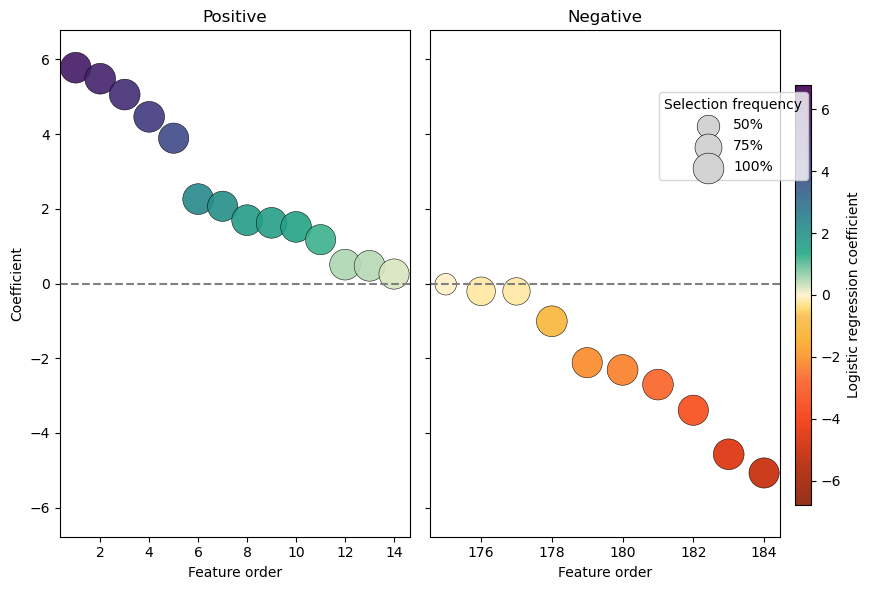

In [15]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

y_max = abs(plot_freq['coef']).max() + 1

norm = TwoSlopeNorm(vmin=-y_max, vcenter=0, vmax=y_max)

cmap_custom = LinearSegmentedColormap.from_list(
    "purple_zero_yellow_red_neg",
    [
        (0.00, "#8a1a01"), # Lowest
        (0.10, "#b52302"),
        (0.20, "#f5350a"),
        (0.30, "#fa6328"),
        (0.35, "#fa9128"),
        (0.40, "#fab028"),
        (0.45, "#f7bc4d"),
        (0.47, "#ffdb70"),
        (0.50, "#fff2cc"), # zero
        (0.60, "#22A884"),
        (0.70, "#2A788E"),
        (0.80, "#414487"),
        (1.00, "#440154"),
    ],
    N=256,
)

df_pos = plot_freq[plot_freq['coef'] > 0]
df_neg = plot_freq[plot_freq['coef'] < 0]

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
fig.subplots_adjust(right=5)

axes[0].scatter(
    df_pos['order'],
    df_pos['coef'],
    s=40 + 450 * df_pos['sel_freq'],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    c=df_pos["coef"],
    norm=norm,
    cmap=cmap_custom
)

axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel("Feature order")
axes[0].set_ylabel("Coefficient")
axes[0].set_title("Positive")
axes[0].set_ylim(-y_max, y_max)

sc= axes[1].scatter(
    df_neg['order'],
    df_neg['coef'],
    s=40 + 450 * df_neg['sel_freq'],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    c=df_neg["coef"],
    norm=norm,
    cmap=cmap_custom
)

axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel("Feature order")
axes[1].set_title("Negative")
axes[1].set_ylim(-y_max, y_max)

cax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Logistic regression coefficient")

size_levels = [0.50, 0.75, 1.00]
handles = [
    plt.scatter([], [], s=40 + 450*s, facecolor="lightgray", edgecolor="black", linewidth=0.4)
    for s in size_levels
]
labels = [f"{int(s*100)}%" for s in size_levels]

plt.legend(
    handles, labels,
    title="Selection frequency",
    loc="upper right",
    bbox_to_anchor=(1.25, 1.0),
    frameon=True
)

plt.tight_layout()
# plt.savefig("Figures/Fig2a.pdf")
plt.show()


---
### Heatmap of coefficients across LOSO CV models. 
Each column represents a model trained with one study held out; and each row a taxon in the final model. Coefficients are represented using the same color scale as in previous figure

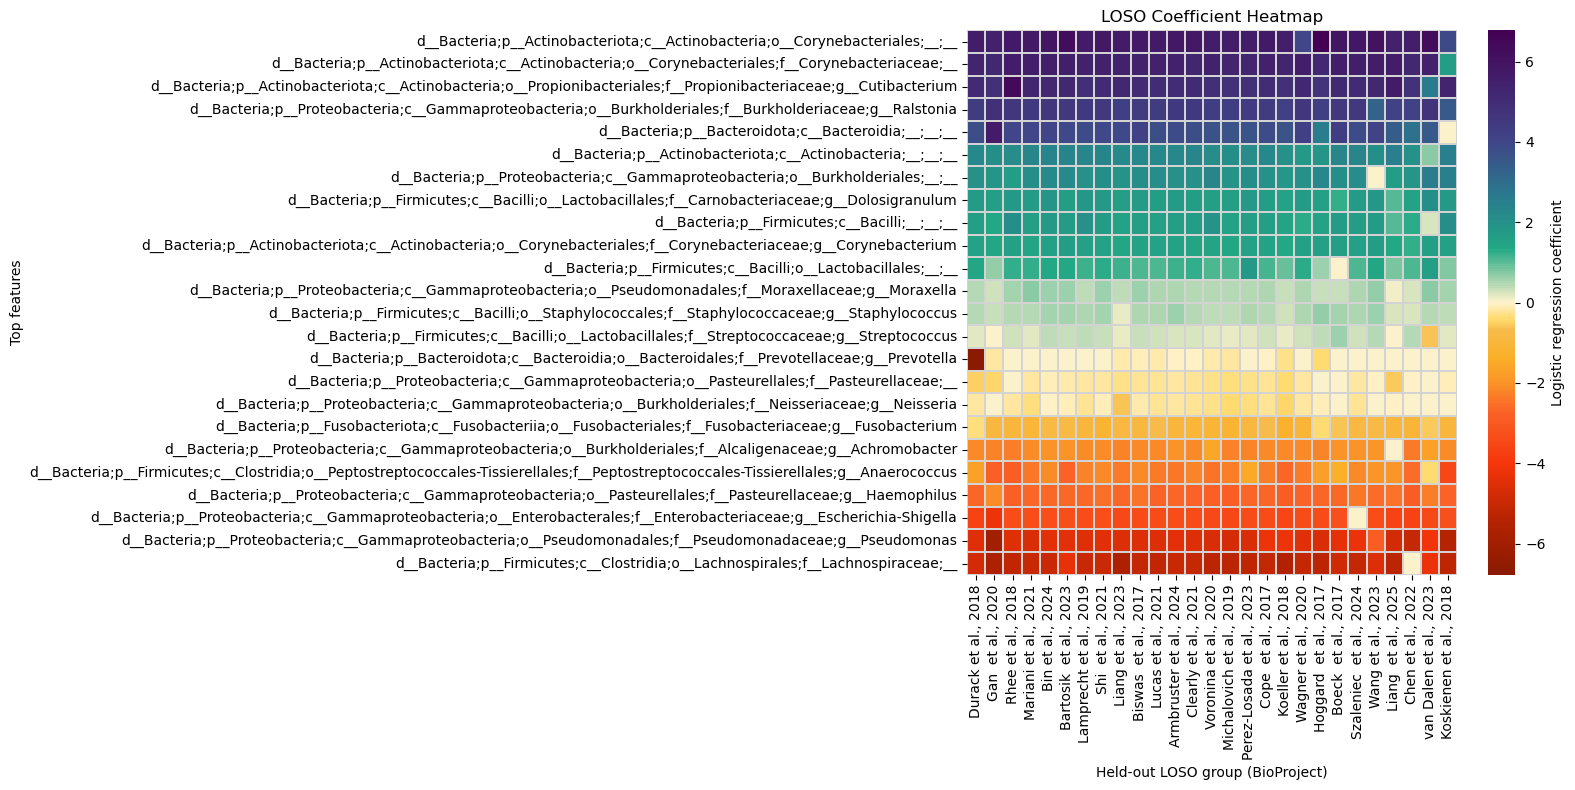

In [16]:
proj_to_citation = dict(
    zip(df['BioProject.Number'],
        df['Citation'])
)

# Heatmap
pos_feats = df_pos.index.to_list()
neg_feats = df_neg.index.to_list()
feature_order = list(dict.fromkeys(pos_feats + neg_feats))
heat = coef_df[feature_order].T

# Order studies by total absolute coefficient magnitude
group_order = coef_df[feature_order].abs().sum(axis=1).sort_values(ascending=False).index
heat = heat[group_order]

# # rename columns
heat = heat.rename(columns=proj_to_citation)

fig_h = max(8, int(0.28 * heat.shape[0]))
fig_w = max(12, int(0.6 * heat.shape[1]))


plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    heat,
    cmap=cmap_custom,
    norm = norm,
    linewidths=0.05,
    linecolor="lightgray",
    cbar_kws={"label": "Logistic regression coefficient"},
)

plt.xlabel("Held-out LOSO group (BioProject)")
plt.ylabel("Top features")
plt.title("LOSO Coefficient Heatmap")
plt.tight_layout()
# plt.savefig("Figures/Fig2b.pdf")
plt.show()

---
### Supplementary Analysis: Influence of 16S rRNA gene hypervariable region on NMWI classification performance

In [17]:
C = 0.9375 # Best regularization parameters for relative abundance

final_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    C=C,
    max_iter=2000
)

In [18]:
hvr_set = merged_meta.copy()
hvr_set = hvr_set.set_index(['16S Region'])

X_hvr = hvr_set[[c for c in hvr_set.columns if c.startswith("d__")]]
y_hvr = hvr_set["Category"].map({'case': False, 'control': True})

feature_names = X_hvr.columns

---
Leave-one-hypervariable region-out analysis was conducted under balanced sample-size conditions across HVR groups. In each analysis, one HVR group was withheld from model training and used as the test set. For each held-out HVR, samples were randombly subsampled 10 times to 97 samples to reduce sample-size imbalance, and balanced accuracy was averaged across subsampling iterations. Despite measurable HVR-associated differences in community composition and dispersion, the NMWI retained above-chance performance across held-out HVRs, with an overall mean balanced accuracy of 68.38% and HVR-specific values ranging from 65% to 71%. These results indicate that HVR choice introduces technical and compositional variation but does not fully account for NMWI discrimination. V1-V4 region was removed since had only 14 samples. 

In [ ]:
# -------------------------------
# Remove V1-V4
# -------------------------------
hvr_ids_all = np.array(X_hvr.index.get_level_values(0))
keep_mask = hvr_ids_all != "V1-V4"

X_no_v14 = X_hvr.loc[keep_mask].copy()
y_no_v14 = y_hvr.loc[keep_mask].copy()
hvr_ids_no_v14 = np.array(X_no_v14.index.get_level_values(0))

# -------------------------------
# Repeated subsampling + LOHO
# -------------------------------
n_repeats = 10
subsample_n = 97

C_grid = np.logspace(-2, 1, 50) 
thresholds = np.linspace(0.1, 0.9, 81)

all_results = []
all_coef_rows = []

rng = np.random.default_rng(123)

# Remove C from final_params if it already exists
base_params = final_params.copy()
base_params.pop("C", None)

for rep in range(n_repeats):

    sampled_indices = []

    for hvr in np.unique(hvr_ids_no_v14):
        hvr_idx = np.where(hvr_ids_no_v14 == hvr)[0]
        n_take = min(subsample_n, len(hvr_idx))

        sampled_idx = rng.choice(
            hvr_idx,
            size=n_take,
            replace=False
        )

        sampled_indices.extend(sampled_idx)

    sampled_indices = np.array(sampled_indices)

    X_rep = X_no_v14.iloc[sampled_indices]
    y_rep = y_no_v14.iloc[sampled_indices].values.ravel()
    hvr_rep = hvr_ids_no_v14[sampled_indices]

    loho = LeaveOneGroupOut()

    for train_idx, test_idx in loho.split(X_rep, y_rep, groups=hvr_rep):

        X_tr = X_rep.iloc[train_idx]
        X_te = X_rep.iloc[test_idx]
        y_tr = y_rep[train_idx]
        y_te = y_rep[test_idx]

        held_out_hvr = np.unique(hvr_rep[test_idx])[0]

        best_ba = -np.inf
        best_C = None
        best_threshold = None
        best_model = None

        if held_out_hvr == "V1-V3":
            C_values = [0.795] # Selected before without subsampling
        else:
            C_values = C_grid

        for C in C_values:

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(
                    **base_params,
                    C=C,
                ))
            ])

            model.fit(X_tr, y_tr)

            y_prob = model.predict_proba(X_te)[:, 1]

            ba_scores = [
                balanced_accuracy_score(y_te, (y_prob >= t).astype(int))
                for t in thresholds
            ]

            idx = np.argmax(ba_scores)

            if ba_scores[idx] > best_ba:
                best_ba = ba_scores[idx]
                best_C = C
                best_threshold = thresholds[idx]
                best_model = model

        y_prob = best_model.predict_proba(X_te)[:, 1]
        y_hat = (y_prob >= best_threshold).astype(int)

        all_results.append({
            "repeat": rep + 1,
            "HVR": held_out_hvr,
            "n_test": len(test_idx),
            "pos_test": int(y_te.sum()),
            "neg_test": int((y_te == 0).sum()),
            "best_C": best_C,
            "threshold": best_threshold,
            "BA": best_ba
        })

        coefs = best_model.named_steps["clf"].coef_.ravel()

        row = pd.Series(
            coefs,
            index=feature_names,
            name=f"rep{rep+1}_{held_out_hvr}"
        )

        all_coef_rows.append(row)

# -------------------------------
# Results
# -------------------------------
loho_subsample_df = pd.DataFrame(all_results)
coef_subsample_df = pd.DataFrame(all_coef_rows)

summary_df_noopt = (
    loho_subsample_df
    .groupby("HVR")
    .agg(
        mean_BA=("BA", "mean"),
        sd_BA=("BA", "std"),
        min_BA=("BA", "min"),
        max_BA=("BA", "max"),
        mean_C=("best_C", "mean"),
        median_C=("best_C", "median"),
        mean_threshold=("threshold", "mean"),
        mean_n=("n_test", "mean"),
        mean_control=("pos_test", "mean"),
        mean_case=("neg_test", "mean")
    )
    .reset_index()
)

summary_df_noopt

,HVR,mean_BA,sd_BA,min_BA,max_BA,mean_C,median_C,mean_threshold,mean_n,mean_control,mean_case
0,V1-V2,0.661106,0.011619,0.645906,0.683145,0.268180,0.058396,0.508,97.0,41.0,56.0
1,V1-V3,0.705155,0.093758,0.546392,0.845361,0.795000,0.795000,0.100,97.0,97.0,0.0
2,V3-V4,0.654760,0.037393,0.598085,0.707353,1.839173,0.058396,0.375,97.0,25.7,71.3
3,V4,0.714469,0.036155,0.668398,0.765985,1.327524,0.372274,0.467,97.0,45.8,51.2


In [24]:
print(f"Mean balanced accuracy for Leave-one-hypervariable region-out: {summary_df_noopt['mean_BA'].mean():.3f}")

Mean balanced accuracy for Leave-one-hypervariable region-out: 0.684


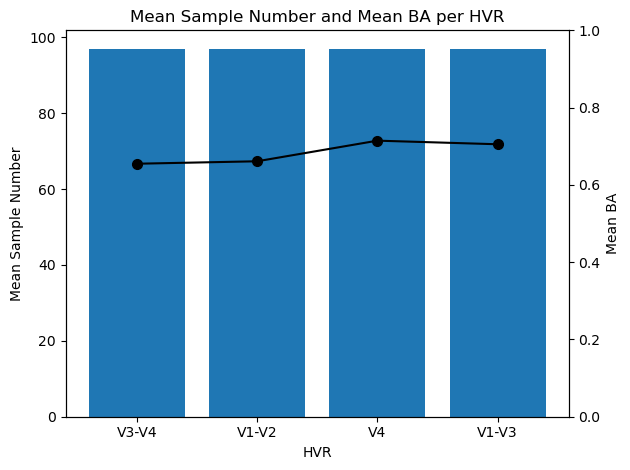

In [25]:
hvr_order = ["V3-V4", "V1-V2", "V4", "V1-V3"]

# -------------------------------
# Aggregate values per HVR
# -------------------------------
plot_df = (
    loho_subsample_df
    .groupby("HVR")
    .agg(
        mean_BA=("BA", "mean"),
        mean_n=("n_test", "mean")
    )
    .reset_index()
)

# Apply custom order
plot_df["HVR"] = pd.Categorical(
    plot_df["HVR"],
    categories=hvr_order,
    ordered=True
)

plot_df = plot_df.sort_values("HVR")

# -------------------------------
# Bar plot + BA dots/line
# -------------------------------
fig, ax1 = plt.subplots()

# Bars = sample number
bars = ax1.bar(
    plot_df["HVR"],
    plot_df["mean_n"],
    # color="blue",
    
)

ax1.set_xlabel("HVR")
ax1.set_ylabel("Mean Sample Number")

# -------------------------------
# Second axis for BA
# -------------------------------
ax2 = ax1.twinx()

ax2.plot(
    plot_df["HVR"],
    plot_df["mean_BA"],
    color="black",
    marker="o",
    linewidth=1.5,
    markersize=7,
    zorder=5
)

ax2.set_ylabel("Mean BA")
ax2.set_ylim(0, 1)

ax1.set_title("Mean Sample Number and Mean BA per HVR")

plt.tight_layout()
plt.show()